In [87]:
# 01. IMPORTAR LIBRERIAS GENERALES ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
# 02. DEFINIR CONFIGURACIONES GENERALES ---

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

In [89]:
# 03. IMPORTAR DATASET train.csv ---

url = "https://raw.githubusercontent.com/estebancardoso96/grupo_3/main/train.csv"
df = pd.read_csv(url)

In [90]:
# 04. REALIZAR UNA INSPECCION INICIAL DEL DATASET train.csv ---

print("AUDITORIA DE VARIABLES DEL DATASET train.csv")

print(f"\nDimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas\n")

audit = pd.DataFrame({
    'dtype':          df.dtypes,
    'nulos':          df.isnull().sum(),
    'pct_nulos':      (df.isnull().sum() / len(df) * 100).round(2),
    'valores_únicos': df.nunique(),
    'moda':           df.mode().iloc[0], # Extrae la primera fila de la moda
    'ejemplo':        df.sample(1).iloc[0], # Genera muestra aleatoria y extrae primera fila
    })
audit

AUDITORIA DE VARIABLES DEL DATASET train.csv

Dimensiones del dataset: 15000 filas × 14 columnas



,dtype,nulos,pct_nulos,valores_únicos,moda,ejemplo
id,int64,0,0.00,15000,0,2763
CustomerId,float64,0,0.00,6309,15793331.00,15689237.00
Surname,str,0,0.00,763,Ch'iu,Hs?
CreditScore,float64,0,0.00,378,678.00,699.00
Geography,str,0,0.00,3,France,France
Gender,str,0,0.00,2,Male,Male
Age,float64,0,0.00,55,38.00,29.00
Tenure,float64,0,0.00,11,2.00,6.00
Balance,float64,0,0.00,3328,0.00,0.00
NumOfProducts,float64,0,0.00,4,2.00,2.00


In [91]:
# 05. COMPLETAR POR GRUPOS LISTA DE VARIABLES A USAR EN EL MODELO ---

# Definir variables numéricas a usar en el modelo
num_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary'
]

# Definir variables categóricas a usar en el modelo
cat_features = [
    'Geography',
    'Gender',
    'NumOfProducts'

]

# Definir variables binarias a usar en el modelo
bin_features = [
    'HasCrCard',
    'IsActiveMember'
]

target = 'Exited'

In [92]:
# 06. ELIMINAR COLUMNAS DEL DATASET QUE NO SE USARAN EN EL MODELO

col_eliminar =[
    'id',
    'CustomerId',
    'Surname'
]

df_depurado = df.drop(columns=col_eliminar)

In [93]:
# 07. REALIZAR ESTADISTICA DESCRIPTIVA DEL DATASET DEPURADO

df_depurado.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,658.13,37.74,5.00,42929.93,1.59,0.78,0.49,118535.94,0.20
std,73.26,8.18,2.81,59820.61,0.53,0.41,0.50,159223.34,0.40
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00
25%,600.00,32.00,3.00,0.00,1.00,1.00,0.00,82696.84,0.00
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,122964.18,0.00
75%,709.00,42.00,7.00,109733.20,2.00,1.00,1.00,156039.30,0.00
max,850.00,72.00,10.00,206329.65,4.00,1.00,1.00,18789543.34,1.00


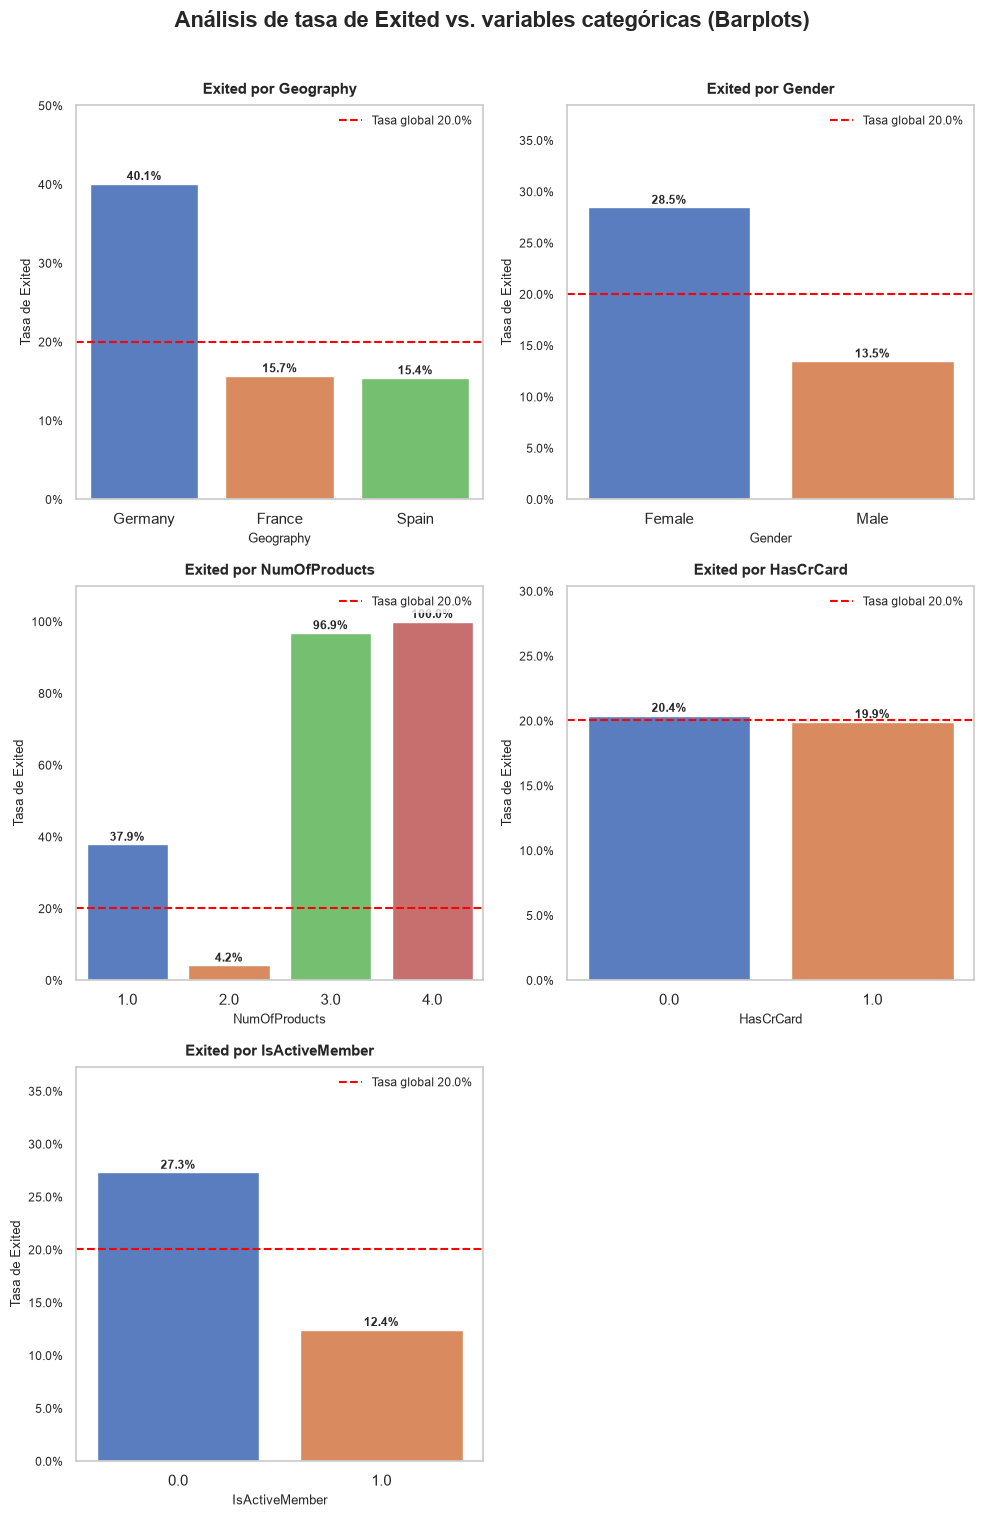

In [94]:
# 08. REALIZAR ANALISIS DE TASA DE ABANDONO VS VARIABLES CATEGORICAS / BINARIAS (BARPLOTS)

import matplotlib.ticker as mtick

# Definir las variables categóricas o binarias a analizar
variables_a_graficar = [
    'Geography',
    'Gender',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember'    
]

# Calcular la tasa base real del dataset
tasa_base = df_depurado[target].mean()

# Configurar el estilo estético de Seaborn
sns.set_theme(style="whitegrid")

# Crear una grilla de 3 filas y 2 columnas (4 cuadrantes)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))
axes_flat = axes.flat

for i, var in enumerate(variables_a_graficar):
    ax = axes_flat[i]

    # Quitar las líneas de la grilla de fondo
    ax.grid(False)

    # Agrupar por la variable y calcular el promedio de Exited
    data_grafico = df_depurado.groupby(var)[target].mean().reset_index().sort_values(by=target, ascending=False)

    # Crear el gráfico de barras
    sns.barplot(
        x=var,
        y=target,
        data=data_grafico,
        palette="muted",
        hue=var,
        legend=False,
        ax=ax
    )

    # Dibujar la línea horizontal de la tasa base
    linea_base = ax.axhline(
        y=tasa_base,
        color='red',
        linestyle='--',
        linewidth=1.5
    )

    # Agregar leyenda en el borde superior derecho del gráfico
    ax.legend(
        [linea_base],
        [f'Tasa global {tasa_base*100:.1f}%'],
        loc='upper right',
        fontsize=8.5,
        frameon=True,
        facecolor='white',
        edgecolor='none'
    )

    # Configurar títulos y etiquetas específicos del cuadrante
    ax.set_title(f"Exited por {var}", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(var, fontsize=9)
    ax.set_ylabel("Tasa de Exited", fontsize=9)

    # Ajustar límite del eje Y dinámicamente dando un margen extra para la leyenda
    max_val = data_grafico[target].max()
    ax.set_ylim(0, max_val + 0.10 if max_val > 0 else 0.3)

    # Formatear el eje Y como porcentaje
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis='y', labelsize=8.5)

    # Agregar las etiquetas de porcentaje sobre cada barra
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height*100:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontsize=8.5, fontweight='bold')

# Apagar cuadrantes vacíos
for j in range(len(variables_a_graficar), len(axes_flat)):
    axes_flat[j].set_visible(False)

# Ajustar el título general de la figura completa
plt.suptitle("Análisis de tasa de Exited vs. variables categóricas (Barplots)", y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

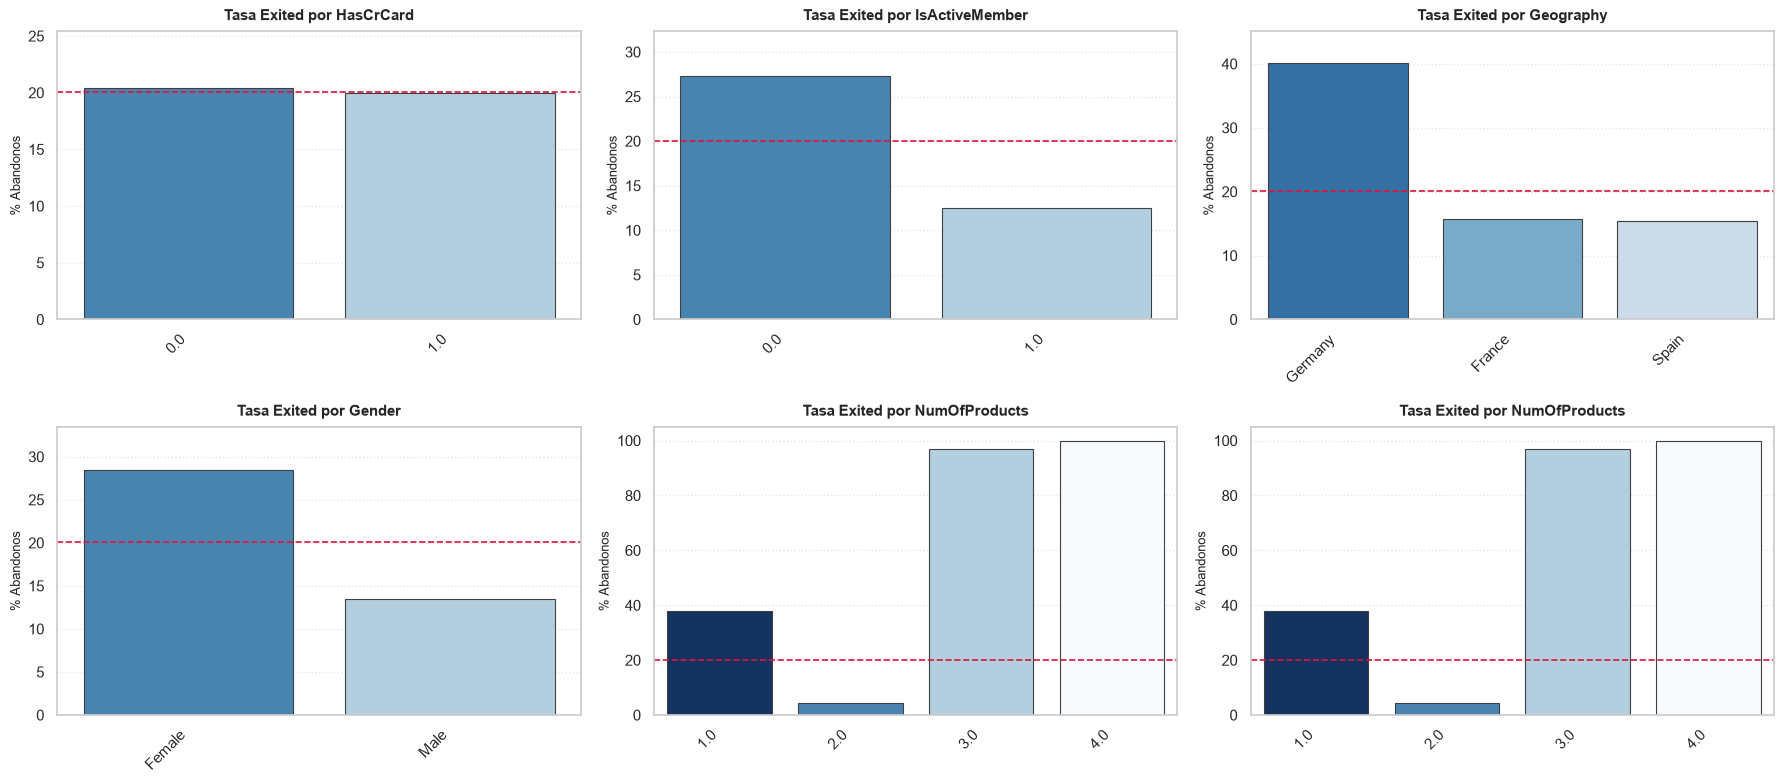

In [95]:
# 09. BARPLOTS DE TASA DE EXITED POR CATEGORIA

import math

#Creamos la copia de trabajo y pasamos el target a porcentaje directo (0 a 100%)
df_plot = df_depurado.copy()
df_plot['Exited_Percent'] = df_plot['Exited'].map({1: 100, 0: 0})

# Agrupamos las listas categóricas y numéricas de la auditoría limpia
# Le agrego temporalmente NumOfProducts a las categoricas para poder graficar la tasa de abandono 
# por cantidad de productos y que quede bien

variables_categoricas = bin_features + cat_features + ['NumOfProducts'] 
variables_numericas = num_features

# Configuramos una cuadrícula fija de 3 columnas
n_cols = 3
# Calculamos las filas necesarias de forma dinámica (redondeando hacia arriba)
n_rows = math.ceil(len(variables_categoricas) / n_cols)

# Creamos la figura principal con un tamaño proporcional al número de filas
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))

# Aplanamos el array de ejes (axes) para poder iterar fácilmente en un solo bucle for
axes = axes.flatten()

# ==============================================================================
# BUCLE EN MATRIZ DE SUBPLOTS
# ==============================================================================
for i, var in enumerate(variables_categoricas):
    # Seleccionamos el eje (subgráfico) actual
    ax = axes[i]
    
    # Agrupamos por la variable, calculamos el porcentaje y ordenamos de mayor a menor riesgo (menos a las categoricas ordinales, que se plotean con el orden natural sin importar el porcentaje de renuncia)
    data_tasa = df_plot.groupby(var)['Exited_Percent'].mean().sort_values(ascending=False).reset_index()
    
    # Dibujamos el barplot en el eje correspondiente (ax=ax)
    sns.barplot(
        x=var, 
        y='Exited_Percent', 
        data=data_tasa, 
        palette='Blues_r', 
        hue=var,
        legend=False,
        ax=ax,
        edgecolor='#404040', 
        linewidth=0.8
    )
    
    # Añadimos la línea roja horizontal con la tasa base del 16% en cada subgráfico 
    ax.axhline(y=20.04, color='crimson', linestyle='--', linewidth=1.2, label='Base (20.04%)' if i == 0 else "")
    
    ax.set_title(f'Tasa Exited por {var}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('') 
    ax.set_ylabel('% Abandonos', fontsize=9)
    ax.set_ylim(0, max(data_tasa['Exited_Percent'].max() + 5, 25))
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment('right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show() 


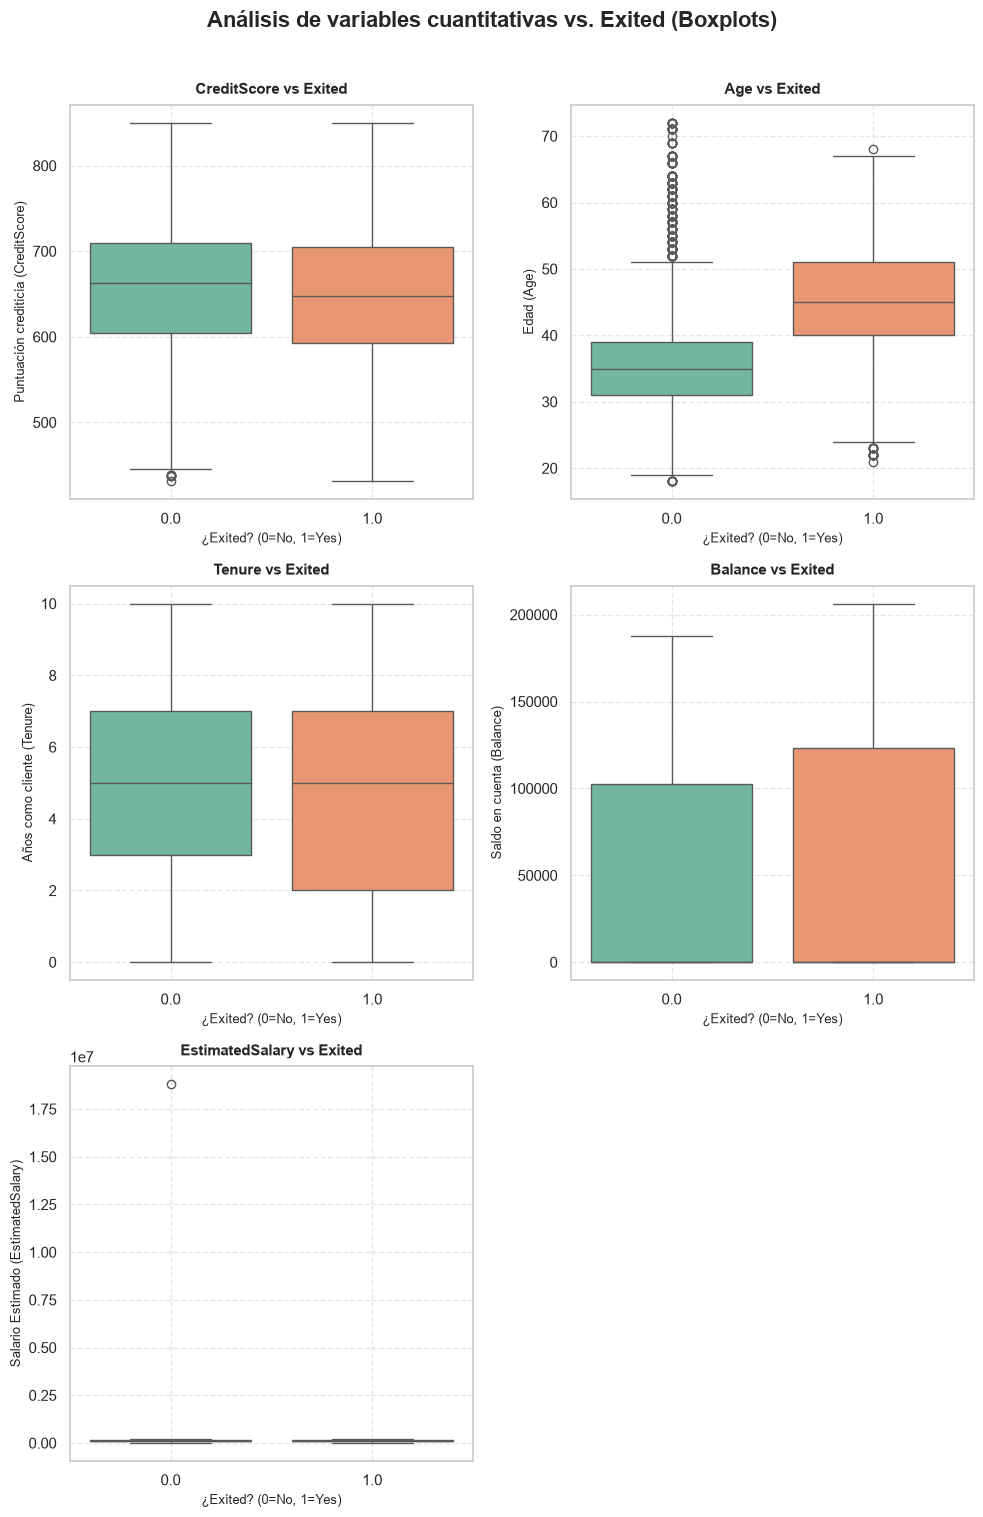

In [96]:
# 10. REALIZAR ANALISIS DE VARIABLES NUMERICAS VERSUS EXITED (BOXPLOTS)

# Definir las variables numéricas a analizar
variables_boxplot = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary'
]

# Configurar el estilo estético de Seaborn
sns.set_theme(style="whitegrid")

# Ajustar a una grilla de 3 filas y 2 columnas (6 cuadrantes en total)
# Redefinir el tamaño de la figura a un formato ideal (10 de base x 15 de alto)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))

# Aplanar la matriz de 4x4 para iterar linealmente del 0 al 15
axes_flat = axes.flat

# Mapear títulos amigables en español
titulos = {
    'CreditScore': 'Puntuación crediticia (CreditScore)',
    'Age': 'Edad (Age)',
    'Tenure': 'Años como cliente (Tenure)',
    'Balance': 'Saldo en cuenta (Balance)',
    'EstimatedSalary': 'Salario Estimado (EstimatedSalary)'
}

# Iterar para construir cada Boxplot
for i, var in enumerate(variables_boxplot):
    ax = axes_flat[i]

    sns.boxplot(
        x=target,
        y=var,
        data=df_depurado,
        ax=ax,
        palette="Set2",
        hue=target,
        legend=False
    )

    # Adaptar títulos y etiquetas al ancho de las 2 columnas
    ax.set_title(f"{var} vs Exited", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel("¿Exited? (0=No, 1=Yes)", fontsize=9)
    ax.set_ylabel(titulos.get(var, var), fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

# Apagar cuadrantes vacíos
for j in range(len(variables_boxplot), len(axes_flat)):
    axes_flat[j].axis('off')

# Generar título general, ajustar layout y mostrar
plt.suptitle("Análisis de variables cuantitativas vs. Exited (Boxplots)", y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

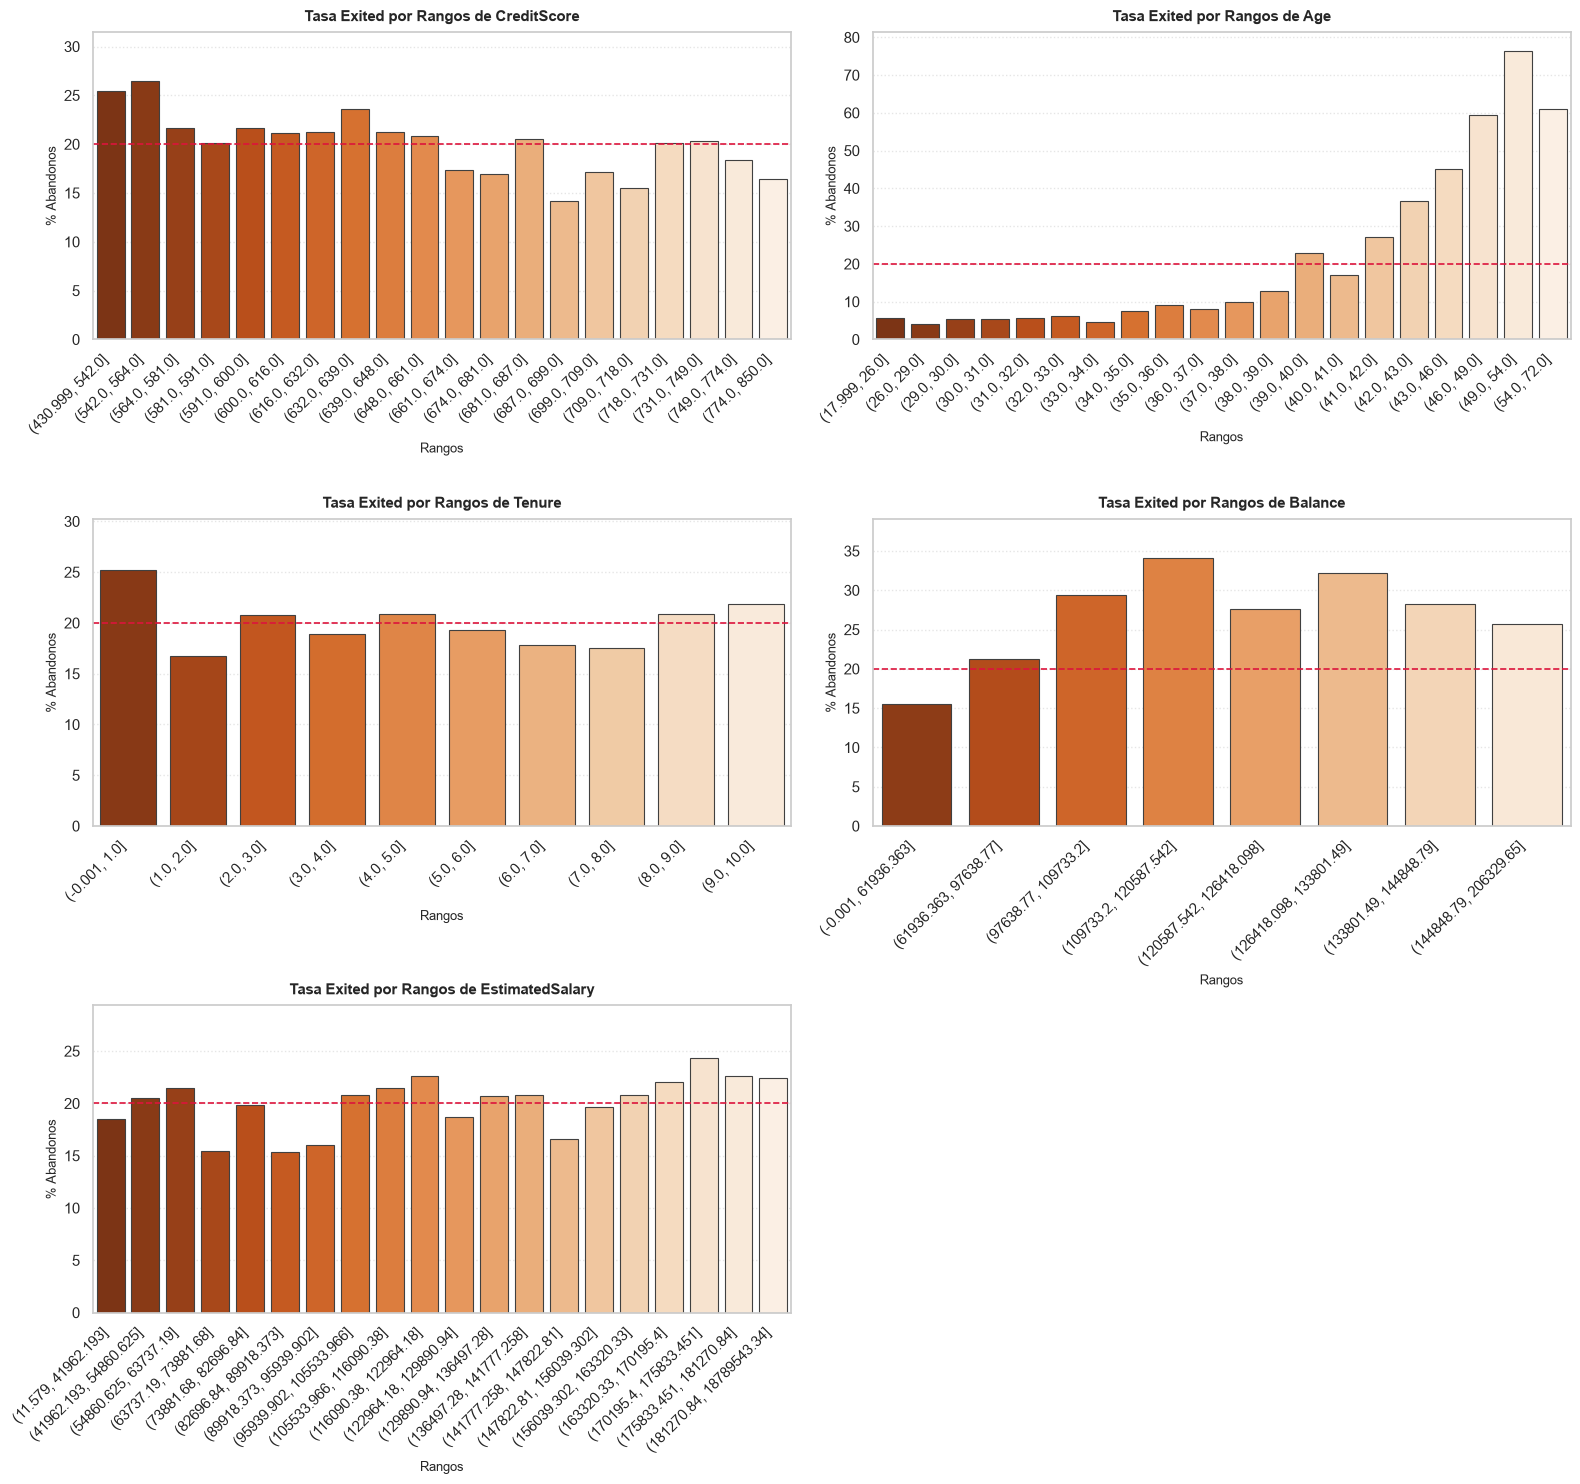

In [97]:
# 11. REALIZAR BARPLOTS DE TASA DE EXITED POR RANGOS DE VARIABLES NUMERICAS

# Hacemos lo mismo pero para las variables numericas, pero a estas las tendremos que dividir en rangos para los graficos de barras. 

n_cols = 2
# Calculamos las filas necesarias de forma dinámica
n_rows = math.ceil(len(variables_numericas) / n_cols) 


fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))

# Aplanamos el array de ejes para poder iterar en un solo bucle limpio (aplasta una matriz 2D en 1D)
axes = axes.flatten()

# ==================================================================================================
# BUCLE EN MATRIZ DE SUBPLOTS
# ==================================================================================================
for i, var in enumerate(variables_numericas):
    ax = axes[i]
    col_intervalo = f'{var}_Rango'
    
    # Segmentamos la variable numérica continua en 10 deciles
    # Usamos duplicates='drop' por seguridad si hay muchos valores idénticos (por lo que algunas variables no quedaran con 10 rangos)
    df_plot[col_intervalo] = pd.qcut(df_plot[var], q=20, duplicates='drop')

    data_tasa_num = (
        df_plot.groupby(col_intervalo, observed=True)['Exited_Percent']
        .mean()
        .sort_index()
        .reset_index()
    )

    data_tasa_num[col_intervalo] = data_tasa_num[col_intervalo].astype(str)
    
    # Dibujamos el barplot en el eje correspondiente
    sns.barplot(
        x=col_intervalo, 
        y='Exited_Percent', 
        data=data_tasa_num, 
        palette='Oranges_r',
        hue=col_intervalo,
        legend=False,
        ax=ax,
        edgecolor='#404040', 
        linewidth=0.8
    )
    
    # Añadimos la línea roja con la tasa base del 16% global de la empresa
    ax.axhline(y=20.04, color='crimson', linestyle='--', linewidth=1.2, label='Base Global (20.04%)' if i == 0 else "")
    
    ax.set_title(f'Tasa Exited por Rangos de {var}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Rangos', fontsize=9) 
    ax.set_ylabel('% Abandonos', fontsize=9)
    ax.set_ylim(0, max(data_tasa_num['Exited_Percent'].max() + 5, 25))
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment('right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

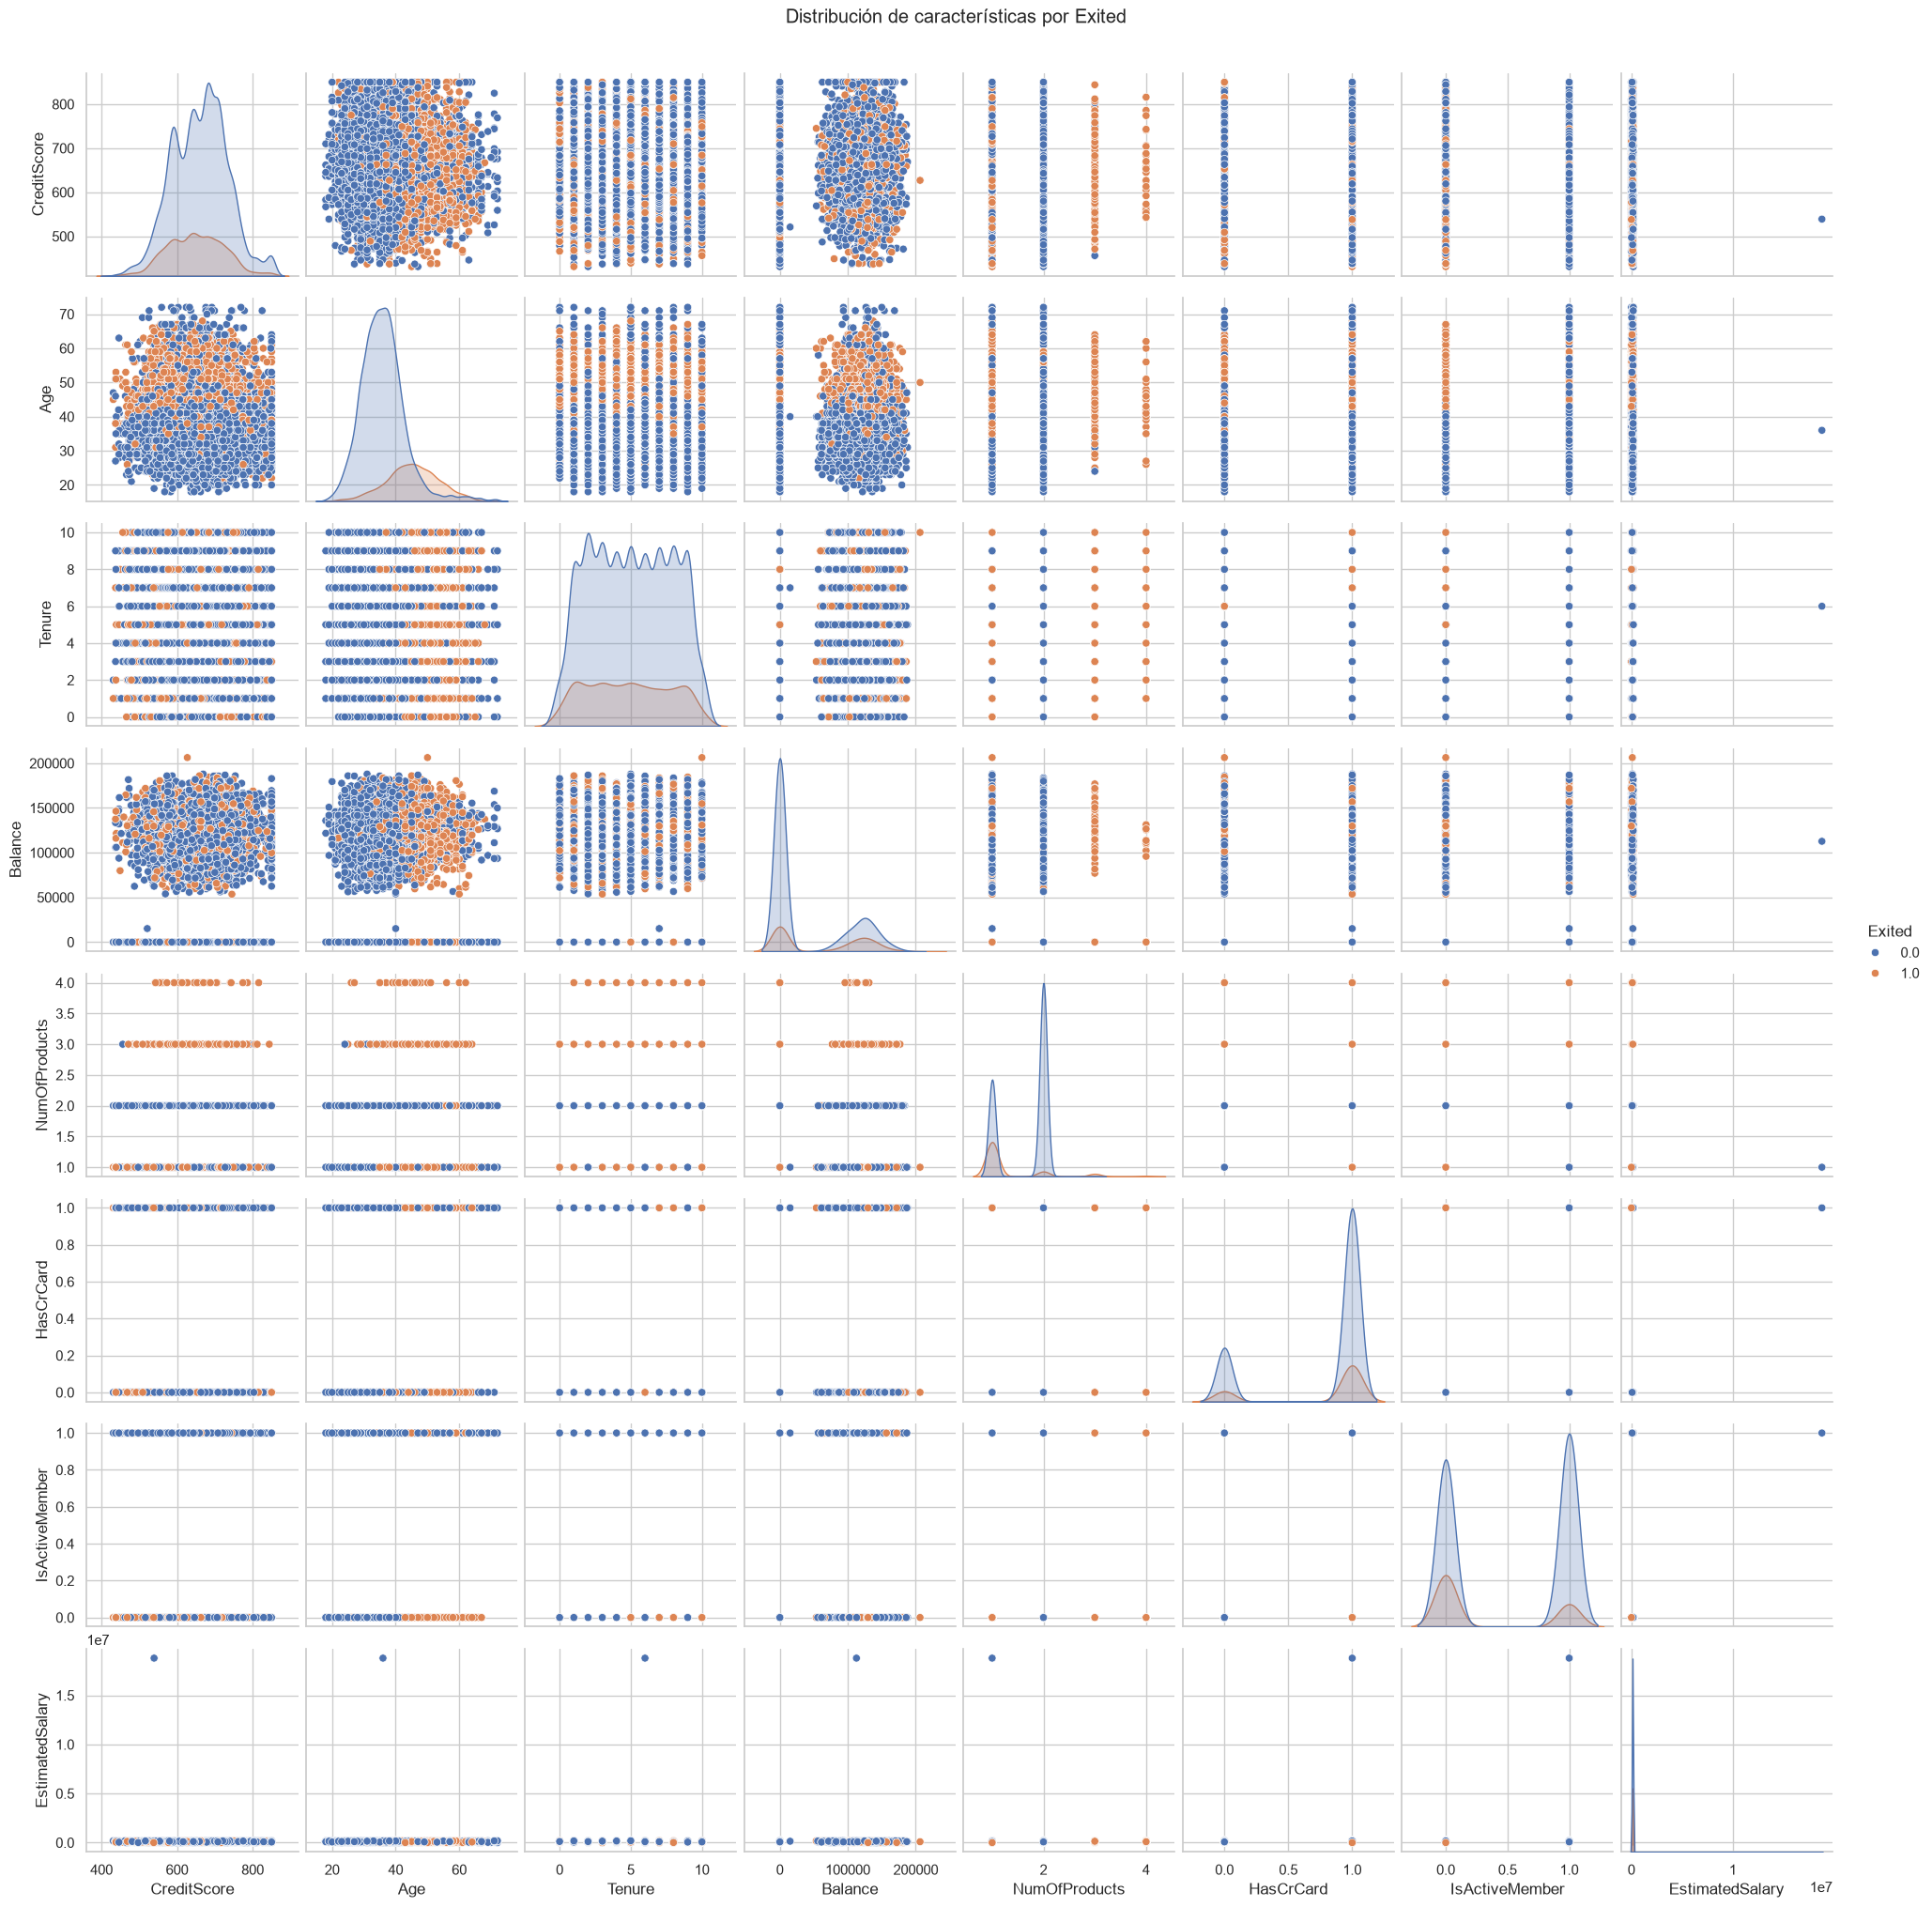

In [98]:
# 12. REALIZAR ANALISIS PAIRPLOT DE VARIABLES NUMERICAS VS EXITED

sns.pairplot(df_depurado, hue='Exited')
plt.suptitle("Distribución de características por Exited", y=1.02)
plt.show()

In [99]:
# 13. COMPLETAR POR GRUPOS LISTA DE VARIABLES A USAR EN EL MODELO

# Definir variables numéricas a usar en el modelo
num_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary'
]

# Definir variables categóricas a usar en el modelo
cat_features = [
    'Geography',
    'Gender',
    'NumOfProducts'

]

# Definir variables binarias a usar en el modelo
bin_features = [
    'HasCrCard',
    'IsActiveMember'
]

target = 'Exited'

In [100]:
# 14. CONSTRUIR COLUMN TRANSFORMER

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Imputar por la mediana y escalar las variables numéricas
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Imputar por la moda y codificar las variables categóricas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Imputar por la moda las variables binarias
binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

# Construir el ColumnTransformer combinando los tres pipelines anteriores
preprocesador = ColumnTransformer(
    transformers=[
        ('escalar_num', numeric_transformer, num_features),
        ('codificar_cat', categorical_transformer, cat_features),
        ('imputar_bin', binary_transformer, bin_features),
    ],
    remainder='drop'
)

In [101]:
# 15. DIVISION DEL DATASET EN CONJUNTO DE ENTRENAMIENTO Y PRUEBA

from sklearn.model_selection import train_test_split

X = df_depurado.drop(columns=[target])
y = df_depurado[target]

# Obtener dataset de entrenamiento y testeo con dataset desbalanceado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  # stratify=y porque dataset desbalanceado

# Mostrar dataset completo sin variable respuesta
display(X)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,636.00,France,Male,36.00,9.00,0.00,1.00,1.00,1.00,53817.23
1,742.00,France,Male,35.00,1.00,0.00,2.00,1.00,1.00,56784.11
2,704.00,France,Female,38.00,5.00,161889.79,1.00,1.00,0.00,79704.12
3,685.00,France,Female,38.00,0.00,0.00,2.00,1.00,0.00,87981.83
4,708.00,France,Male,34.00,10.00,0.00,2.00,0.00,0.00,64340.65
...,...,...,...,...,...,...,...,...,...,...
14995,580.00,Germany,Female,37.00,3.00,141806.00,2.00,1.00,0.00,151871.84
14996,516.00,Spain,Female,38.00,4.00,0.00,2.00,1.00,0.00,170886.01
14997,538.00,Germany,Female,43.00,7.00,129745.10,1.00,1.00,0.00,1408.68
14998,616.00,France,Female,27.00,7.00,0.00,2.00,0.00,1.00,98820.09


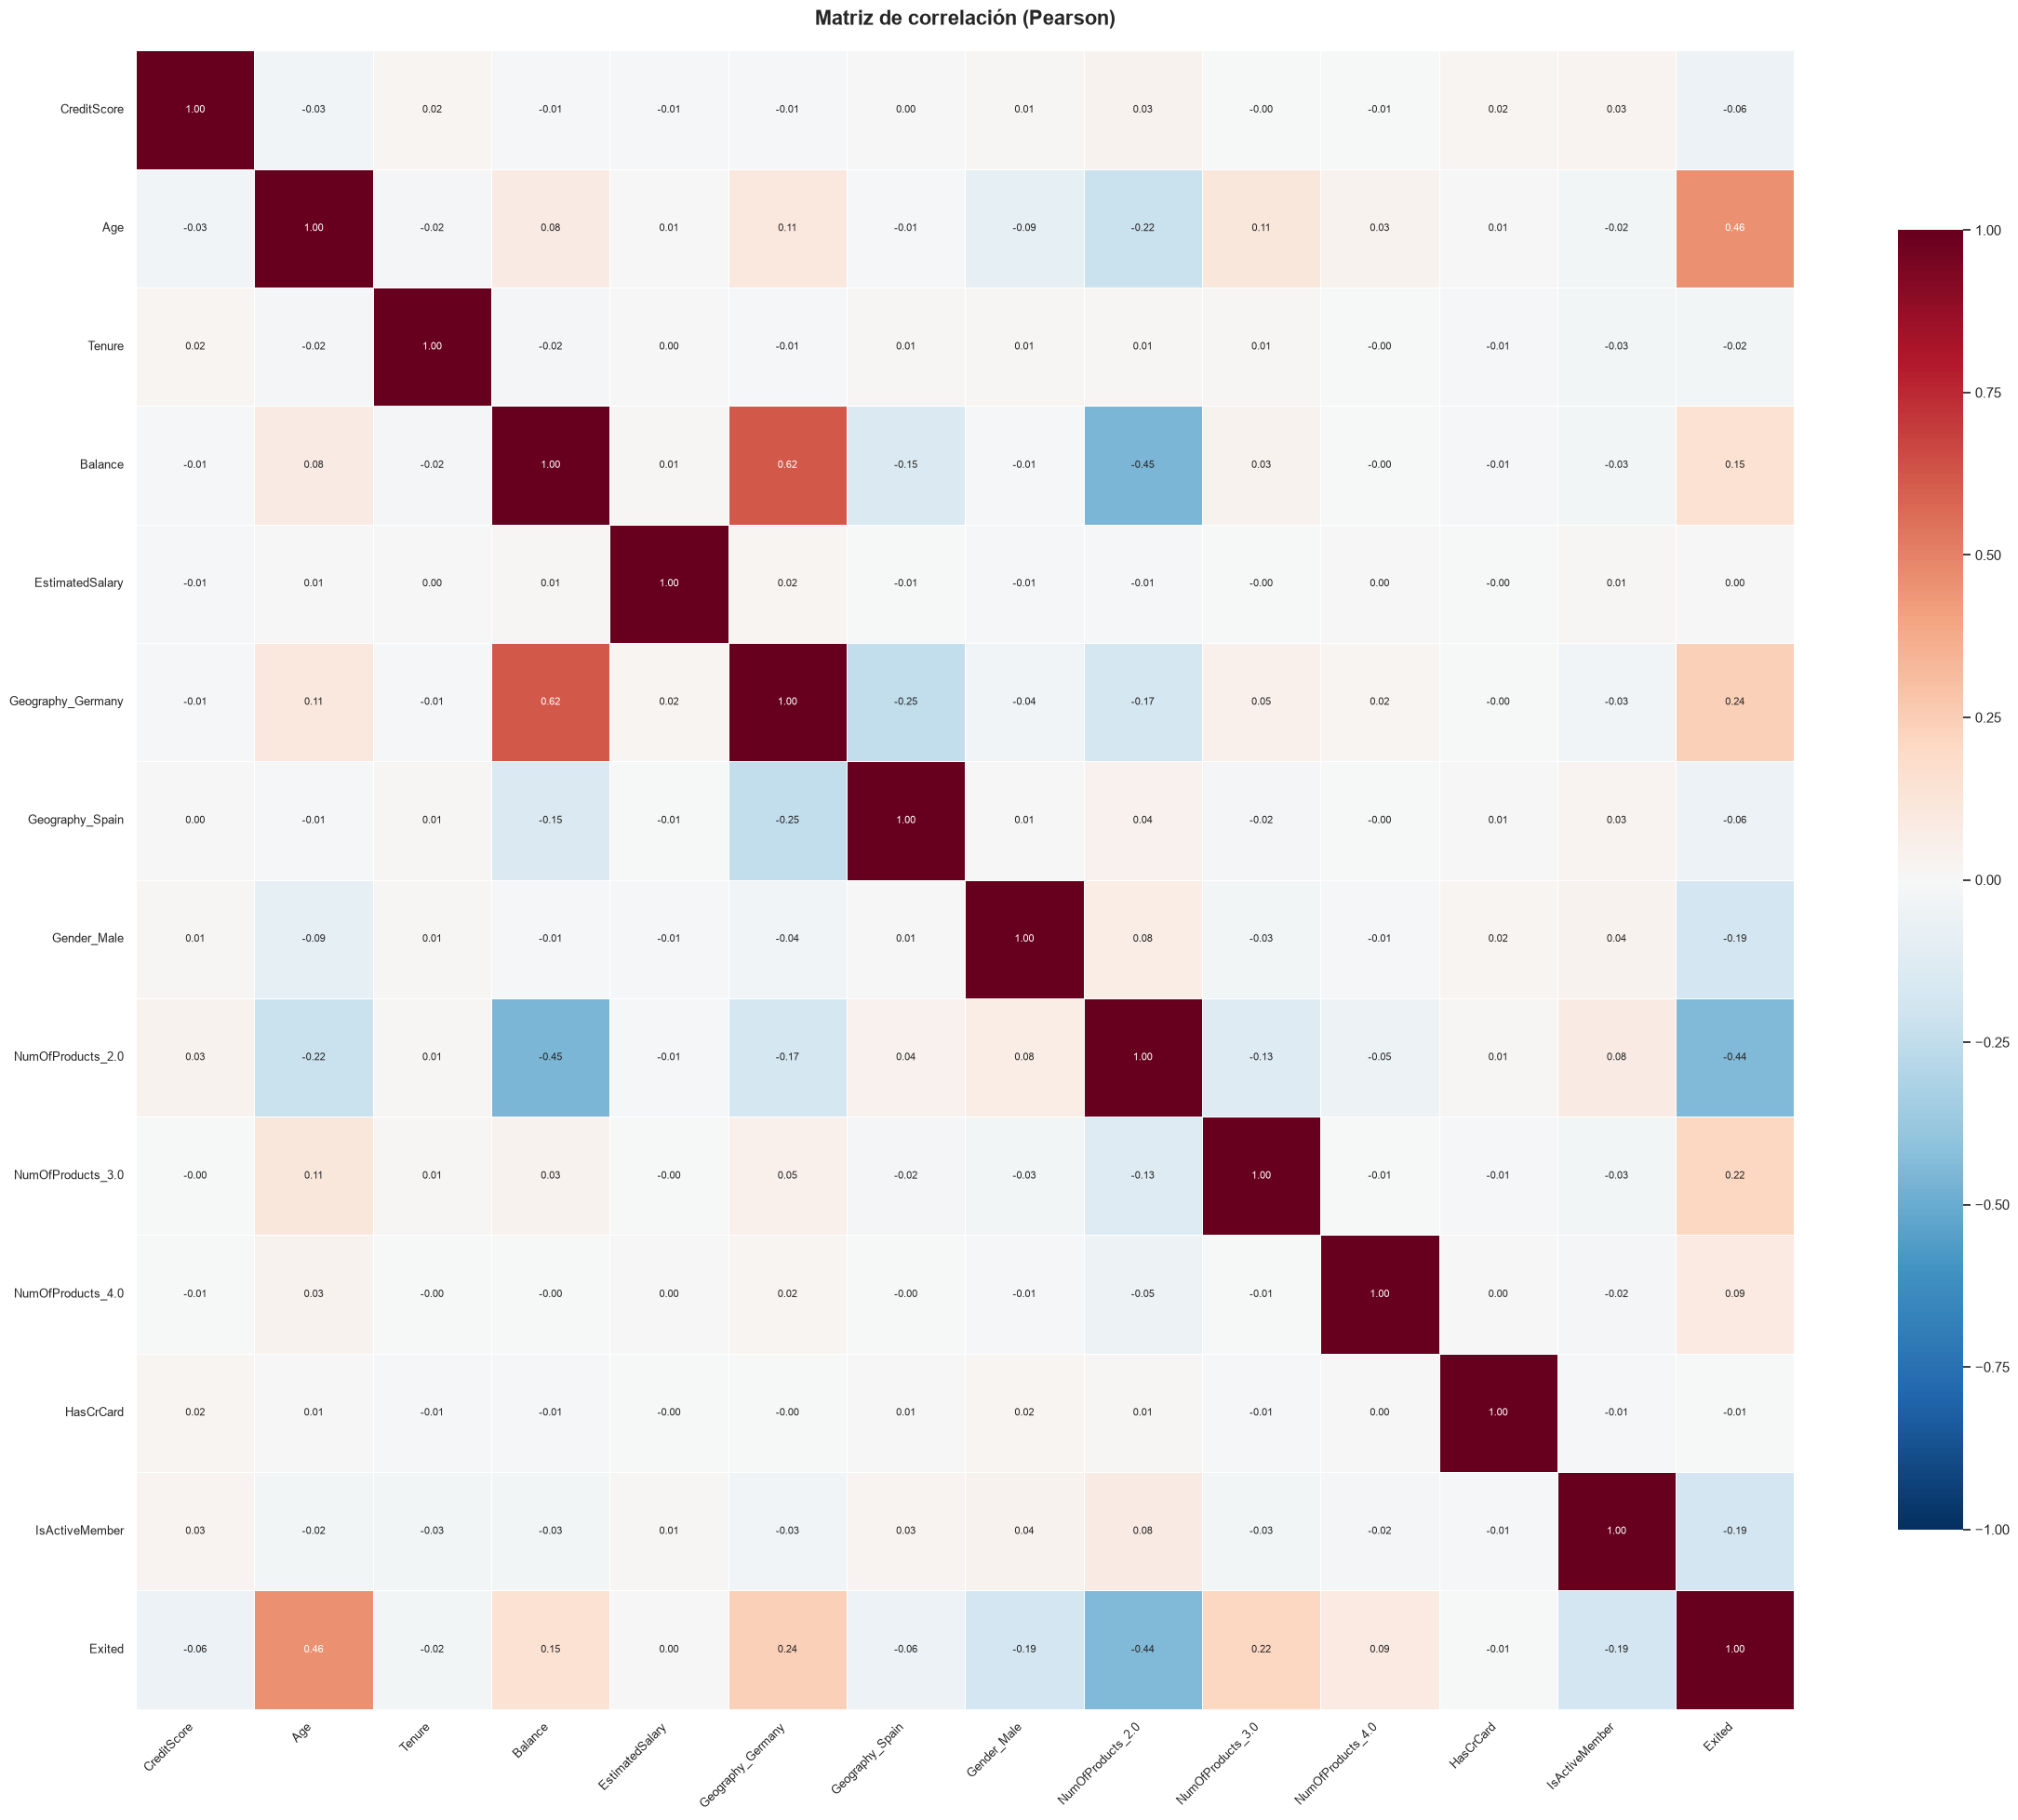

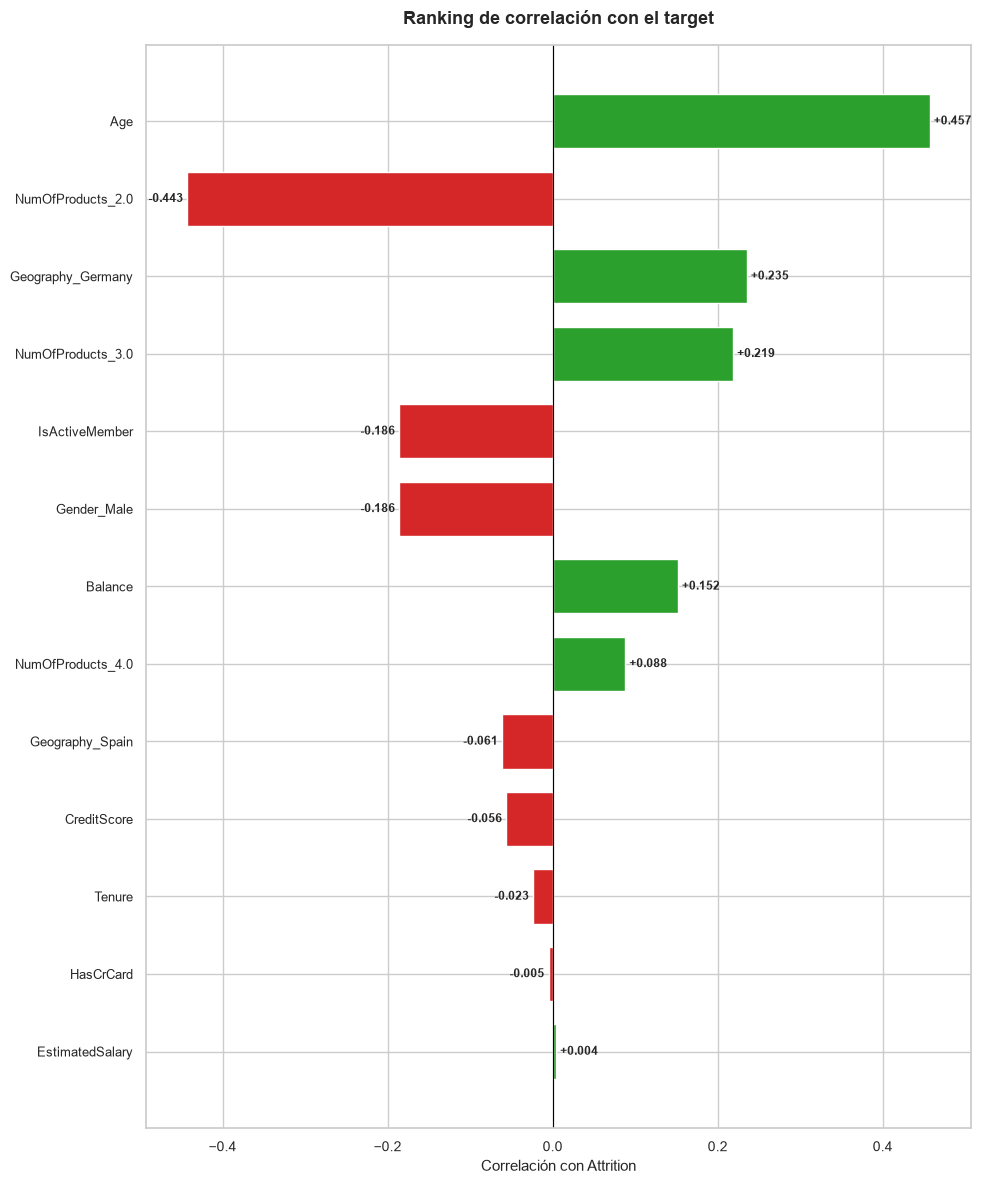

Ranking ordenado por correlación absoluta:
Age                  0.46
NumOfProducts_2.0   -0.44
Geography_Germany    0.23
NumOfProducts_3.0    0.22
IsActiveMember      -0.19
Gender_Male         -0.19
Balance              0.15
NumOfProducts_4.0    0.09
Geography_Spain     -0.06
CreditScore         -0.06
Tenure              -0.02
HasCrCard           -0.01
EstimatedSalary      0.00
Name: Exited, dtype: float64


In [102]:
# 16. REALIZAR ANALISIS DE CORRELACION CON EL TARGET ---

# PREPARAR DATOS PARA ANALISIS DE CORRELACION ----------------------------------

# Entrenar el preprocesador con X_train y aplicar la transformación
X_train_transf = preprocesador.fit_transform(X_train)

# Aplicar a todo X el preprocesador entrenado con X_train
X_transf = preprocesador.transform(X)

# Recuperar nombres de columnas resultantes para poner en DataFrame
ohe_cat_cols = list(preprocesador.named_transformers_['codificar_cat'].get_feature_names_out(cat_features))
imp_bin_cols = list(preprocesador.named_transformers_['imputar_bin'].get_feature_names_out(bin_features))
col_names_final = num_features + ohe_cat_cols + imp_bin_cols

# Construir un DataFrame de datos transformados con nombres más el target
df_num = pd.DataFrame(X_transf, columns=col_names_final, index=X.index)
df_num['Exited'] = y

# CONSTRUIR MATRIZ DE CORRELACION ----------------------------------------------

# Generar matriz de correlación de todo X con datos transformados
corr = df_num.corr()

# Definir tamaño de la representación gráfica de la matriz
plt.figure(figsize=(24, 20))

# Definir una paleta de colores para el ranking de correlación
PALETA = ['#2ca02c', '#d62728'] # Verde para positivo, Rojo para negativo

# Dibujar el mapa de calor ajustando el tamaño de la letra (annot_kws)
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.75}, # Encoge la barra de color para que no deforme el mapa
            annot_kws={"size": 8})     # Reducir la letra de los números dentro de las celdas

# Rotar las etiquetas para que no se encimen
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.title('Matriz de correlación (Pearson)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# -- GENERAR RANKING DE CORRELACION CON EL TARGET ------------------------------

# Extraer columna target y ordenar por valor absoluto del coef. correlación
corr_target = corr['Exited'].drop('Exited')
ranking = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)

# Aumentamos el alto a 12 para que cada barra tenga su propio espacio respirable
fig, ax = plt.subplots(figsize=(10, 12))

colores = [PALETA[0] if v >= 0 else PALETA[1] for v in ranking]

# Ajustar el grosor de las barras con height=0.7 para dejar separación entre ellas
ax.barh(ranking.index, ranking.values, color=colores, height=0.7)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlabel('Correlación con Attrition', fontsize=11)
ax.set_title('Ranking de correlación con el target', fontweight='bold', fontsize=13, pad=15)
ax.invert_yaxis()

# Reducir el tamaño de letra de los nombres de las variables
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=10)

# Corregir las etiquetas de texto para que no colisionen con las barras
for i, v in enumerate(ranking.values):
    # El desplazamiento (offset) depende de si el valor es positivo o negativo
    offset = 0.005 if v >= 0 else -0.005
    alignment = 'left' if v >= 0 else 'right'

    ax.text(v + offset, i, f'{v:+.3f}',
            va='center',
            ha=alignment,
            fontsize=8.5,
            fontweight='semibold')

# Añadir margen a los lados del gráfico para que los textos de las puntas no se corten
ax.set_xlim(ranking.min() - 0.05, ranking.max() + 0.05)

plt.tight_layout()
plt.show()

print('Ranking ordenado por correlación absoluta:')
print(ranking.round(3))

In [103]:
# 17. ENTRENAR RANDOM FOREST CON PIPELINE Y GRIDSEARCHCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

pipe_rf = Pipeline(steps=[
    ('pre', preprocesador),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

print(f"Mejores parámetros (RF): {grid_rf.best_params_}")
print(f"Mejor ROC-AUC (RF):      {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores parámetros (RF): {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Mejor ROC-AUC (RF):      0.9282


In [104]:
# 18. EVALUAR EL MODELO RANDOM FOREST USANDO EL SUBSET DE TEST DE TRAIN.CSV

from sklearn.metrics import auc

y_pred = grid_rf.best_estimator_.predict(X_test)

auc = roc_auc_score(y_test, grid_rf.best_estimator_.predict_proba(X_test)[:, 1])
print(f"\n{'='*53}")
print(f"(ROC-AUC RF test = {auc:.4f})")
print(f"{'='*53}")
print(classification_report(y_test, y_pred))    


(ROC-AUC RF test = 0.9246)
              precision    recall  f1-score   support

         0.0       0.95      0.88      0.91      2399
         1.0       0.62      0.82      0.71       601

    accuracy                           0.87      3000
   macro avg       0.79      0.85      0.81      3000
weighted avg       0.89      0.87      0.87      3000



Calculando Permutation Importance (esto puede tomar unos segundos)...


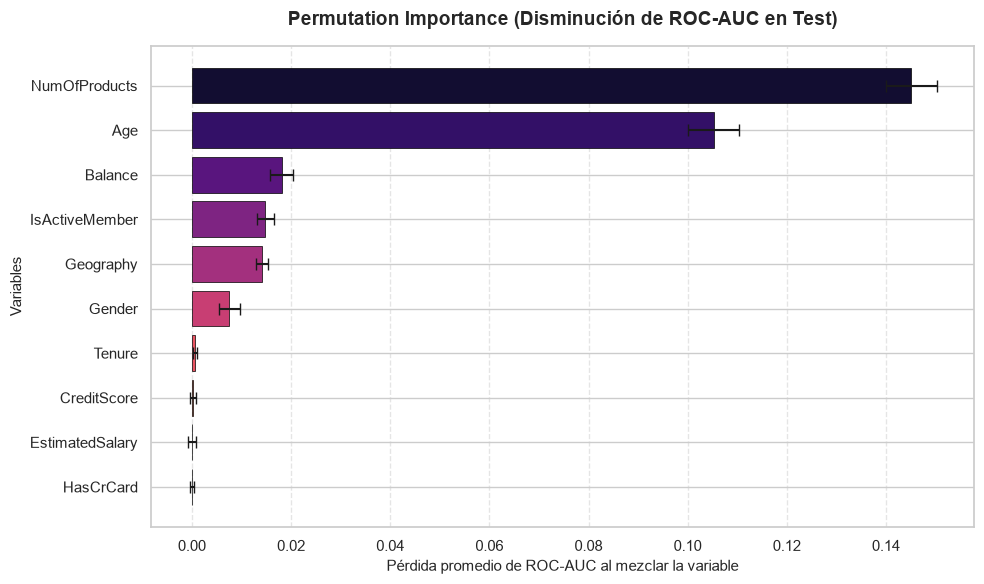

Ranking numérico de impacto:


,Variable,Importancia_Media,Desviacion_Estandar
6,NumOfProducts,0.15,0.01
3,Age,0.11,0.01
5,Balance,0.02,0.00
8,IsActiveMember,0.01,0.00
1,Geography,0.01,0.00
2,Gender,0.01,0.00
4,Tenure,0.00,0.00
0,CreditScore,0.00,0.00
9,EstimatedSalary,0.00,0.00
7,HasCrCard,0.00,0.00


In [ ]:
# 19. REALIZAR ANALISIS DE IMPORTANCIA DE VARIABLES (PERMUTATION IMPORTANCE)

from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculando Permutation Importance (esto puede tomar unos segundos)...")

# 1. Ejecutar Permutation Importance
# Usamos el mejor modelo (best_estimator_) sobre los datos de prueba
resultado_permutacion = permutation_importance(
    estimator=grid_rf.best_estimator_,
    X=X_test,
    y=y_test,
    scoring='roc_auc',  # Usamos la misma métrica que en GridSearchCV
    n_repeats=10,       # Cantidad de veces que se mezcla cada columna para promediar
    random_state=42,
    n_jobs=-1           # Usa todos los procesadores disponibles
)

# 2. Consolidar los resultados en un DataFrame
df_importancia = pd.DataFrame({
    'Variable': X_test.columns,
    'Importancia_Media': resultado_permutacion.importances_mean,
    'Desviacion_Estandar': resultado_permutacion.importances_std
})

# Ordenar las variables de mayor a menor importancia
df_importancia = df_importancia.sort_values(by='Importancia_Media', ascending=False)

# 3. Visualizar los resultados con un Barplot
plt.figure(figsize=(10, 6))

# Usamos matplotlib puro (plt.barh) que maneja perfectamente los errores pre-calculados (xerr)
plt.barh(
    y=df_importancia['Variable'],
    width=df_importancia['Importancia_Media'],
    xerr=df_importancia['Desviacion_Estandar'],
    capsize=4,
    color=sns.color_palette('magma', len(df_importancia)),
    edgecolor='black',
    linewidth=0.5
)

# Invertir el eje Y para que la variable más importante quede en la parte superior
plt.gca().invert_yaxis()

plt.title('Permutation Importance (Disminución de ROC-AUC en Test)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pérdida promedio de ROC-AUC al mezclar la variable', fontsize=11)
plt.ylabel('Variables', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Mostrar la tabla exacta en pantalla
print("Ranking numérico de impacto:")
display(df_importancia)

In [ ]:
# 20. IMPORTAR DATASET test.csv

url_test = "https://raw.githubusercontent.com/estebancardoso96/grupo_3/main/test.csv"
df_test = pd.read_csv(url_test)

In [ ]:
# 21. REALIZAR UNA INSPECCION INICIAL DEL DATASET test.csv ---

print("AUDITORIA DE VARIABLES DEL DATASET test.csv")

print(f"\nDimensiones del dataset: {df_test.shape[0]} filas × {df_test.shape[1]} columnas\n")

audit = pd.DataFrame({
    'dtype':          df_test.dtypes,
    'nulos':          df_test.isnull().sum(),
    'pct_nulos':      (df_test.isnull().sum() / len(df_test) * 100).round(2),
    'valores_únicos': df_test.nunique(),
    'moda':           df_test.mode().iloc[0], # Extrae la primera fila de la moda
    'ejemplo':        df_test.sample(1).iloc[0], # Genera muestra aleatoria y extrae primera fila
    })
audit

AUDITORIA DE VARIABLES DEL DATASET test.csv

Dimensiones del dataset: 10000 filas × 13 columnas



,dtype,nulos,pct_nulos,valores_únicos,moda,ejemplo
id,int64,0,0.00,10000,15000,24576
CustomerId,float64,0,0.00,5224,15593365.00,15806360.00
Surname,str,0,0.00,711,Ch'iu,Y?an
CreditScore,float64,0,0.00,366,678.00,635.00
Geography,str,0,0.00,3,France,Germany
Gender,str,0,0.00,2,Male,Male
Age,float64,0,0.00,55,37.00,42.00
Tenure,float64,0,0.00,11,2.00,9.00
Balance,float64,0,0.00,2502,0.00,133616.38
NumOfProducts,float64,0,0.00,4,2.00,1.00


In [ ]:
# 22. GENERAR SAMPLE SUBMISSION DE test.csv PARA MODELO BASE DE RANDOM FOREST ---

# Eliminar en test.csv las mismas columnas que se descartaron en train.csv
df_test_depurado = df_test.drop(columns=col_eliminar)

# Generar las probabilidades de abandono (Exited) usando el mejor modelo entrenado
y_test_prob = grid_rf.best_estimator_.predict_proba(df_test_depurado)[:, 1]

# Crear un DataFrame con el 'id' original y la probabilidad generada
df_resultados = pd.DataFrame({
    'id': df_test['id'],
    'Exited': y_test_prob
})

# Visualizar las primeras filas para comprobar la estructura
print("Vista previa de las probabilidades:")
print(df_resultados.head())

# Exportar las probabilidades a un archivo CSV sin incluír el índice
df_resultados.to_csv('submission_modelo_base_rf.csv', index=False)
print("\nArchivo 'submission_modelo_base_rf.csv' exportado exitosamente.")

Vista previa de las probabilidades:
      id  Exited
0  15000    0.05
1  15001    0.82
2  15002    0.06
3  15003    0.96
4  15004    0.26

Archivo 'submission_modelo_base_rf.csv' exportado exitosamente.
